PyTocrh 数学计算GPU加速，模型加载推理，下载分cpu/gpu，根据硬件适配
vscode安装python，jupyter依赖，运行需要安装ipykernal

张量计算

In [ ]:
from importlib.util import find_spec
from importlib.metadata import version
if find_spec('torch') is None:
    raise Exception("torch未安装")

print("torch:",version('torch'))



torch: 2.14.1


In [46]:
# 打印torch类的属性和方法
import torch
print(dir(torch))

['AVG', 'AcceleratorError', 'AggregationType', 'AliasDb', 'AnyType', 'Argument', 'ArgumentSpec', 'AwaitType', 'BFloat16Storage', 'BFloat16Tensor', 'BenchmarkConfig', 'BenchmarkExecutionStats', 'Block', 'BoolStorage', 'BoolTensor', 'BoolType', 'BufferDict', 'ByteStorage', 'ByteTensor', 'CallStack', 'Capsule', 'CharStorage', 'CharTensor', 'ClassType', 'Code', 'CompilationUnit', 'CompleteArgumentSpec', 'ComplexDoubleStorage', 'ComplexFloatStorage', 'ComplexType', 'ConcreteModuleType', 'ConcreteModuleTypeBuilder', 'DeepCopyMemoTable', 'DeserializationStorageContext', 'DeviceObjType', 'DictType', 'DisableTorchFunction', 'DisableTorchFunctionSubclass', 'DispatchKey', 'DispatchKeySet', 'DoubleStorage', 'DoubleTensor', 'EnumType', 'ErrorReport', 'Event', 'ExcludeDispatchKeyGuard', 'ExecutionPlan', 'FatalError', 'FileCheck', 'FloatStorage', 'FloatTensor', 'FloatType', 'FunctionSchema', 'Future', 'FutureType', 'Generator', 'GradScaler', 'Gradient', 'Graph', 'GraphExecutorState', 'HalfStorage', '

张量创建：torch类的静态方法tensor创建标量或者张量，静态方法arange创建张量


这两个方法形参里的关键词参数
dtype ,dtype类型的变量有： torch类的float32属性，float属性，
out 结果分配到另一个地址的变量
require_grad： 是否开启对tensor实例的梯度追踪
pin_memory



In [20]:
import torch
# 标量
a=torch.tensor(1) 
a_arr=torch.tensor([0,1,2])
# 向量、一位张量
b=torch.arange(8)

print(a,b,a_arr)
print(len(b),b.shape)

# 3阶张量
print(torch.ones([3,4,5]))
print(torch.zeros([2,3,4]))
print(torch.randn([2,3,4]))

print(b.reshape([2,4])) # 如果元素和不是8，RuntimeError


tensor(1) tensor([0, 1, 2, 3, 4, 5, 6, 7]) tensor([0, 1, 2])
8 torch.Size([8])
tensor([[[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]],

        [[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]],

        [[1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1.]]])
tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])
tensor([[[ 0.9925,  0.4969,  0.6922, -0.7094],
         [-0.5555,  0.1414,  0.4092, -0.7866],
         [-0.2704, -0.5197,  0.4415, -0.0768]],

        [[-0.4557, -0.0033, -2.5224,  0.2627],
         [-1.9269,  0.7225,  0.6501,  1.6845],
         [-1.0985, -1.2988, -0.4513, -0.1328]]])
tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]])


In [ ]:
import torch
b=torch.arange(8)
c=b.reshape([2,4])
print(c.sum())
d=b.reshape([2,2,2])
print(d)
# 求和 降维
print(d.sum()) 
print(d.sum(dim=0)) # 降1维
print(d.sum(dim=1))

# 求和不降维
print(d.sum(dim=0,keepdim=True)) 

tensor(28)
tensor([[[0, 1],
         [2, 3]],

        [[4, 5],
         [6, 7]]])
tensor(28)
tensor([[ 4,  6],
        [ 8, 10]])
tensor([[ 2,  4],
        [10, 12]])
tensor([[[ 4,  6],
         [ 8, 10]]])


In [25]:
A = torch.arange(24,dtype=torch.float32).reshape(2, 3, 4)
B=A.clone()

print(A)
print(A+B)
print(A*B)

print(A.mean()) # 平均值
print(A.sum()/A.numel())

tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])
tensor([[[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.]],

        [[24., 26., 28., 30.],
         [32., 34., 36., 38.],
         [40., 42., 44., 46.]]])
tensor([[[  0.,   1.,   4.,   9.],
         [ 16.,  25.,  36.,  49.],
         [ 64.,  81., 100., 121.]],

        [[144., 169., 196., 225.],
         [256., 289., 324., 361.],
         [400., 441., 484., 529.]]])
tensor(11.5000)
tensor(11.5000)


点积(Tensor类dot静态方法)，向量积(Tensor类mv静态方法)，矩阵乘积(Tensor类mm静态方法)，


张量乘积用matmul
输入维度 matmul行为
1D × 1D	点积（返回标量）
2D × 2D	就是 mm
1D × 2D	向量×矩阵
2D × 1D	矩阵×向量
3D+	batch matmul

In [ ]:
import torch
x=torch.arange(4)
y=torch.arange(4)
print(x,y,torch.dot(x,y),torch.sum(x*y))


tensor([0, 1, 2, 3]) tensor([0, 1, 2, 3]) tensor(14) tensor(14)


In [ ]:
import torch
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=torch.arange(4,dtype=torch.float32)
# 矩阵-向量积
print(A,B,torch.mv(A,B)) # B是4*1

# 矩阵-矩阵积，
C=torch.ones(4,3)
print(torch.mm(A,C))

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]]) tensor([0., 1., 2., 3.]) tensor([ 14.,  38.,  62.,  86., 110.])
tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])


范数

Tensor类的norm静态方法 求取张量的L2范数

In [19]:
import torch
print(torch.norm(torch.tensor([3.,4.])))

tensor(5.)


梯度追踪，对b进行反向传播，a的grad属性发生变化

tensor实例的backward方法，计算损失函数对模型参数的梯度

关键词参数 gradient,ratain_graph,create_graph,input
retain_graph，保留计算图(不加的话，反向传播完就释放计算图内存)



In [45]:
import torch
a=torch.arange(4,dtype=torch.float)
a.requires_grad_(True) # 开启梯度追踪，也可以在创建时开启，加关键词参数
print(a.requires_grad) # 检查梯度追踪是否开启
b= torch.dot(a,a)
print(a) # 
print(b)
b.backward() # 只能进行一次
print(a.grad)
# b.backward()



True
tensor([0., 1., 2., 3.], requires_grad=True)
tensor(14., grad_fn=<DotBackward0>)
tensor([0., 2., 4., 6.])


矢量化计算 和 手动实现矩阵计算 差距在哪

In [ ]:
import torch
n = 50000
a = torch.ones(n)
b = torch.ones(n)
c=torch.zeros(n)


tensor([1., 1., 1.,  ..., 1., 1., 1.])


In [21]:
from llm_kernel.performance import Timer
timer =Timer()
timer.start()

for i in range(n):
    c[i]=a[i]+b[i]
timer.stop()

timer.start()
d=a+b
timer.stop()
print(timer.times)

[1.0213932991027832, 0.004254579544067383]


正态分布

torch.normal(mean,std,size) 生成 元素均值为mean，标准差是std，格式是size的张量

In [ ]:
import torch
y=torch.normal(0,1,[2,4]) 
print(y)

tensor([[ 2.0050,  1.3081,  0.1044,  1.2671],
        [ 0.0728, -2.5117, -0.3314, -0.1054]])


1400 1400


d:\python\Lib\site-packages\llm_kernel\plot\vector_2d.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


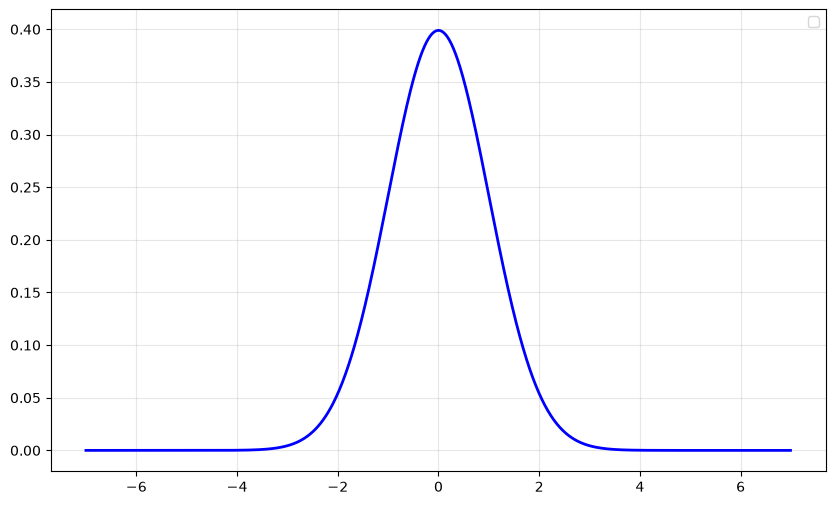

In [ ]:
from llm_kernel.math import normal
import numpy as np
x=x = np.arange(-7, 7, 0.01)
y=normal(x,0,1)

# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 6))
# plt.plot(x, y, 'b-', linewidth=2)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()

from llm_kernel.plot import vector
vector(x,y)
